# Player profile — Harry Kane

Example **player-centric** view across all shots in the five-match sample. Speedometer gauges (Plotly) summarize mean module and phase scores.

In [1]:
from pathlib import Path
import pandas as pd
from aws_football.bsq_reports import (
    merge_shot_tables,
    player_summary,
    display_plotly_player_dashboard,
    display_plotly_speedometer,
    display_plotly_phase_speedometer,
    display_player_speedometers,
    FINISHING_EXECUTION_INDEX_COL,
)

PLAYER = 'Harry Kane'
df = merge_shot_tables()
kane = df[df.player_name == PLAYER].copy()
kane[['match_folder','family','shot_result','finishing_execution_index','technique_mechanics_score','placement_score','strike_quality_score','P3_score','P4_score','P5_score']]


,match_folder,family,shot_result,finishing_execution_index,technique_mechanics_score,placement_score,strike_quality_score,P3_score,P4_score,P5_score
20,Bayern_Hamburg,carry_self_created,successfulShot,67.842967,65.698511,85.687422,81.315027,73.659779,80.728923,26.358356
62,Frankfurt_Bayern,open_play,successfulShot,44.672449,81.029204,32.506728,69.476828,86.005745,86.602039,61.665688
108,Union_Bayern,open_play,blockedShot,15.869272,NaN,15.286841,NaN,63.867803,39.554462,80.711477
112,Union_Bayern,open_play,blockedShot,12.416135,NaN,17.769121,NaN,69.870841,29.100071,60.547067
125,Union_Bayern,header,successfulShot,49.296196,40.533630,64.608249,NaN,42.140679,20.508329,61.261499
126,Union_Bayern,carry_self_created,blockedShot,41.383020,58.035040,77.539146,58.874717,46.226659,37.671455,84.737492


In [2]:
from pathlib import Path
import pandas as pd
from aws_football.bsq_reports import (
    merge_shot_tables,
    player_summary,
    display_plotly_player_dashboard,
    display_plotly_speedometer,
    display_plotly_phase_speedometer,
    display_player_speedometers,
    FINISHING_EXECUTION_INDEX_COL,
)

PLAYER = 'Harry Kane'
df = merge_shot_tables()
kane = df[df.player_name == PLAYER].copy()
kane[['match_folder','family','shot_result','finishing_execution_index','technique_mechanics_score','placement_score','strike_quality_score','P3_score','P4_score','P5_score']]


,match_folder,family,shot_result,finishing_execution_index,technique_mechanics_score,placement_score,strike_quality_score,P3_score,P4_score,P5_score
20,Bayern_Hamburg,carry_self_created,successfulShot,67.842967,65.698511,85.687422,81.315027,73.659779,80.728923,26.358356
62,Frankfurt_Bayern,open_play,successfulShot,44.672449,81.029204,32.506728,69.476828,86.005745,86.602039,61.665688
108,Union_Bayern,open_play,blockedShot,15.869272,NaN,15.286841,NaN,63.867803,39.554462,80.711477
112,Union_Bayern,open_play,blockedShot,12.416135,NaN,17.769121,NaN,69.870841,29.100071,60.547067
125,Union_Bayern,header,successfulShot,49.296196,40.533630,64.608249,NaN,42.140679,20.508329,61.261499
126,Union_Bayern,carry_self_created,blockedShot,41.383020,58.035040,77.539146,58.874717,46.226659,37.671455,84.737492


In [3]:
means = player_summary(df, PLAYER)
show = [FINISHING_EXECUTION_INDEX_COL,'technique_mechanics_score','placement_score','strike_quality_score','approach_prep_score','arrival_receiving_score','P3_score','P4_score','P5_score']
pd.DataFrame({'metric': show, 'mean_score': [round(means[c],1) for c in show]})


,metric,mean_score
0,finishing_execution_index,38.6
1,technique_mechanics_score,61.3
2,placement_score,48.9
3,strike_quality_score,69.9
4,approach_prep_score,80.6
5,arrival_receiving_score,86.7
6,P3_score,63.6
7,P4_score,49.0
8,P5_score,62.5


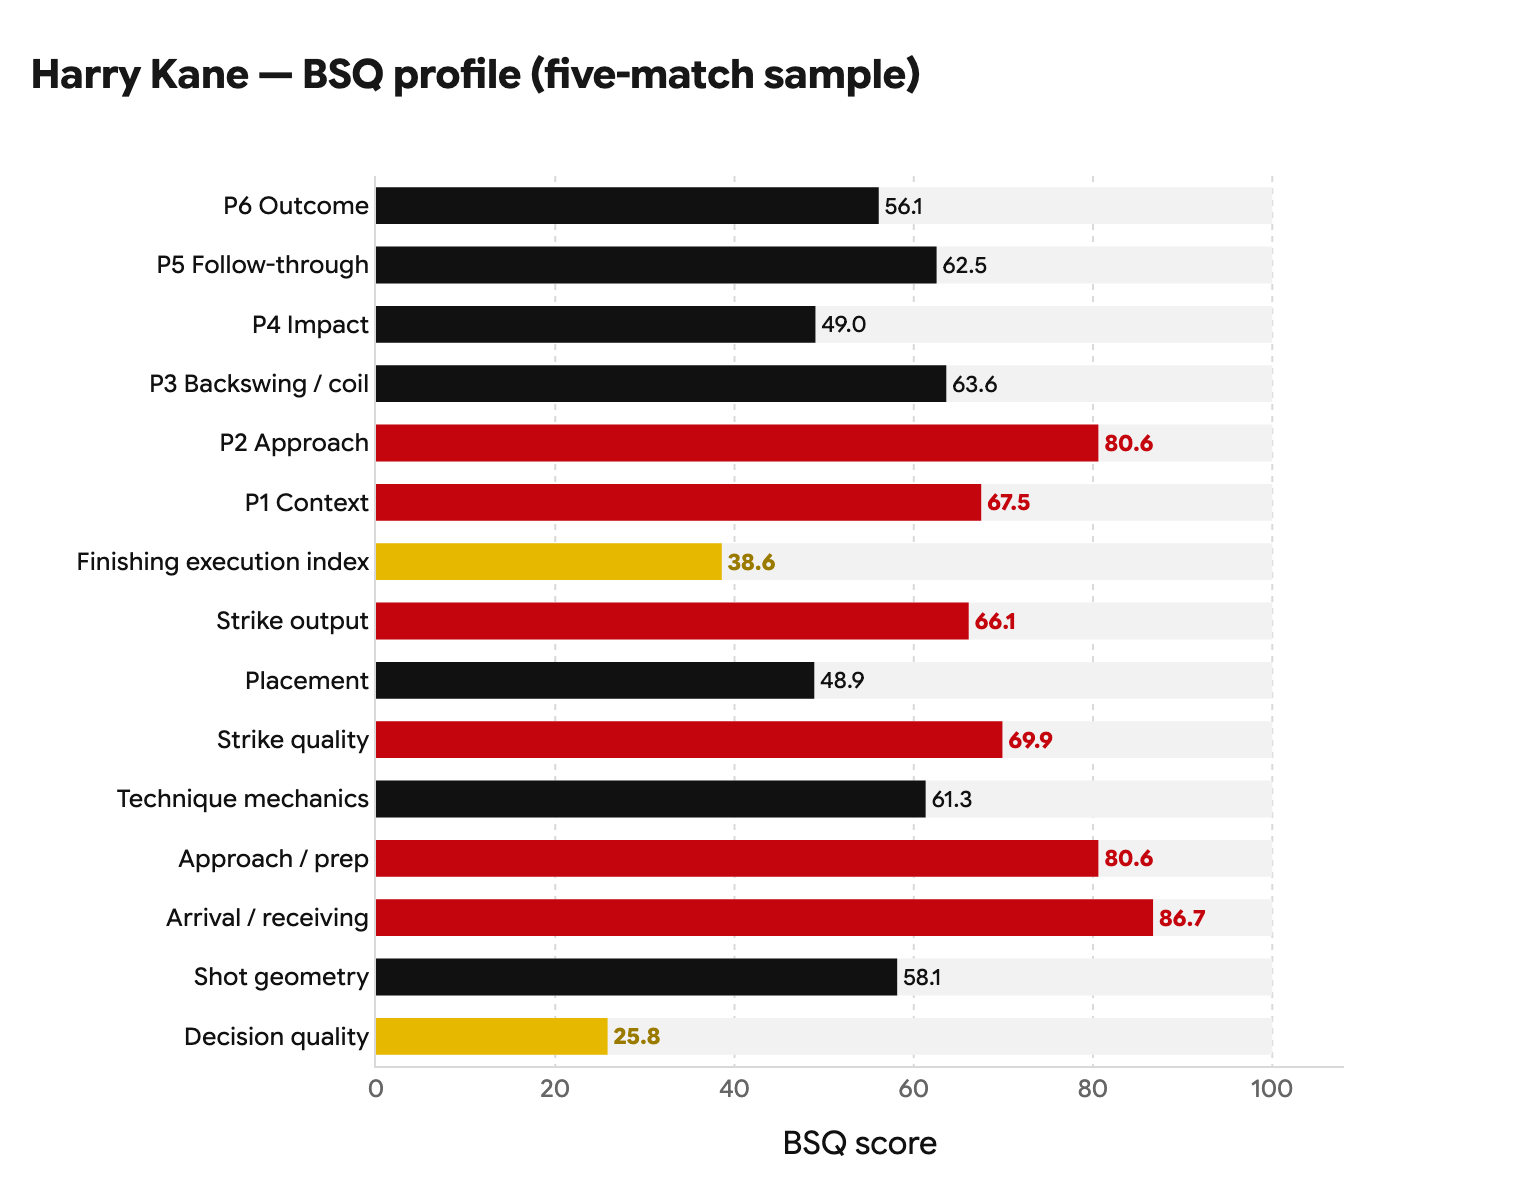

In [4]:
display_plotly_player_dashboard(means, PLAYER)


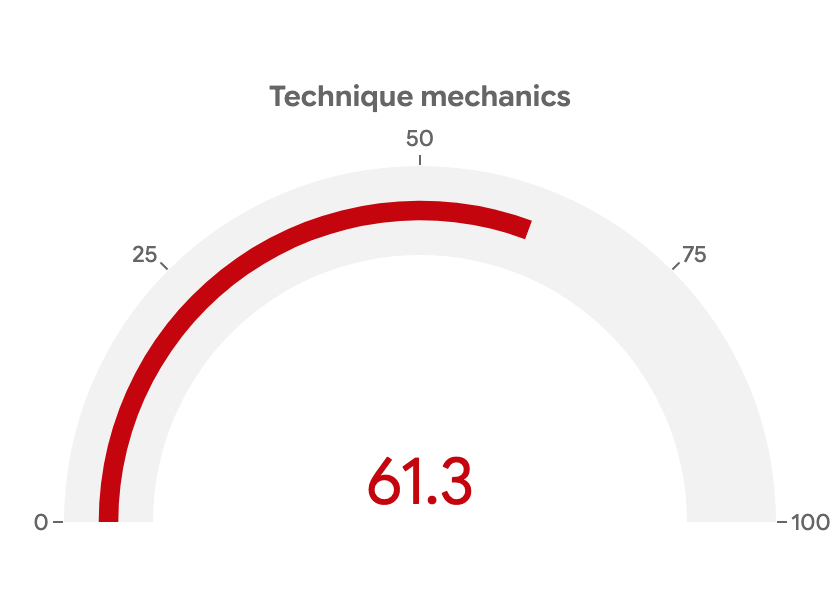

In [5]:
display_plotly_speedometer('Technique mechanics', means['technique_mechanics_score'])


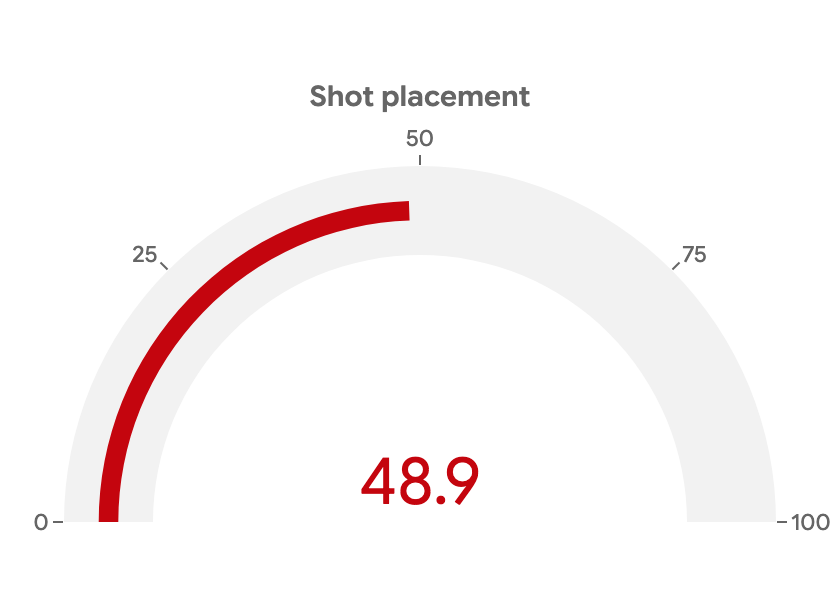

In [6]:
display_plotly_speedometer('Shot placement', means['placement_score'])


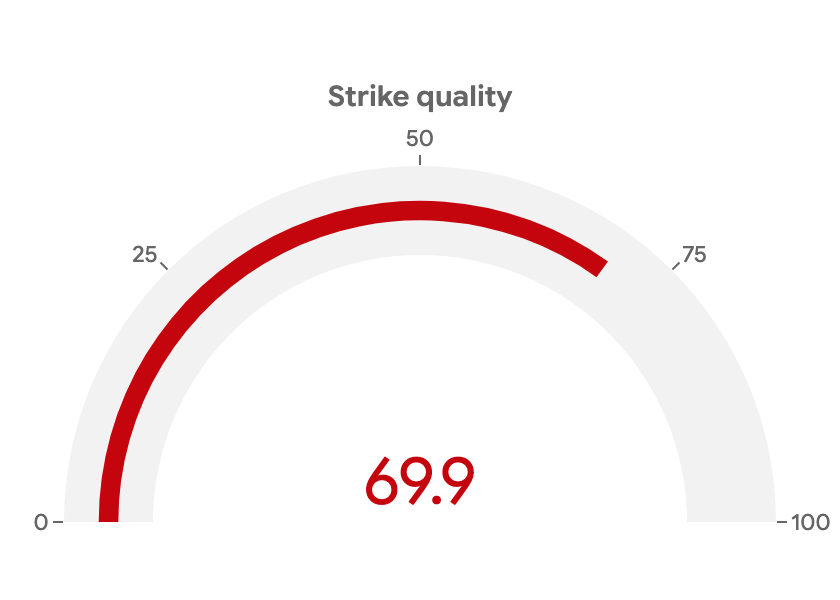

In [7]:
display_plotly_speedometer('Strike quality', means['strike_quality_score'])


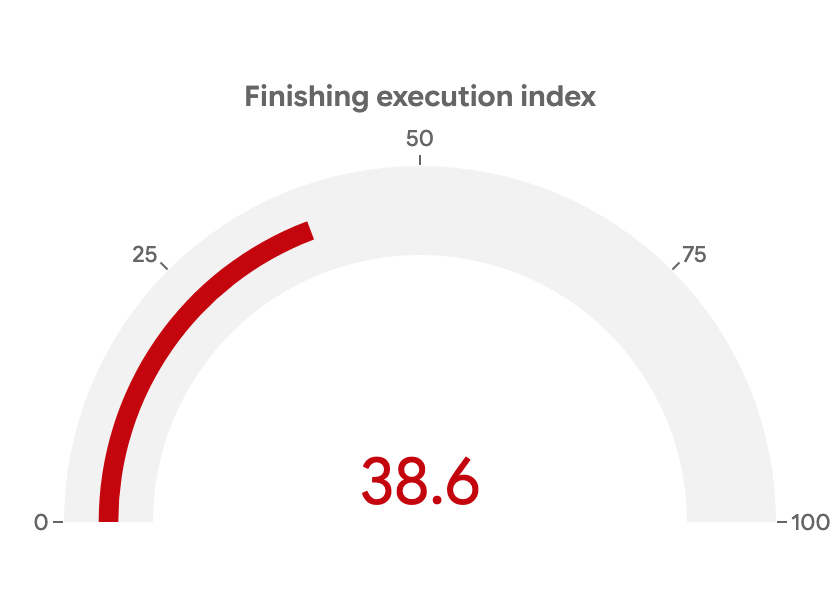

In [8]:
display_plotly_speedometer('Finishing execution index', means['finishing_execution_index'])


### Highest mean scores (≥ 60)

Every BSQ metric with a shot-average **≥ 60** gets a speedometer (no top-N cap).


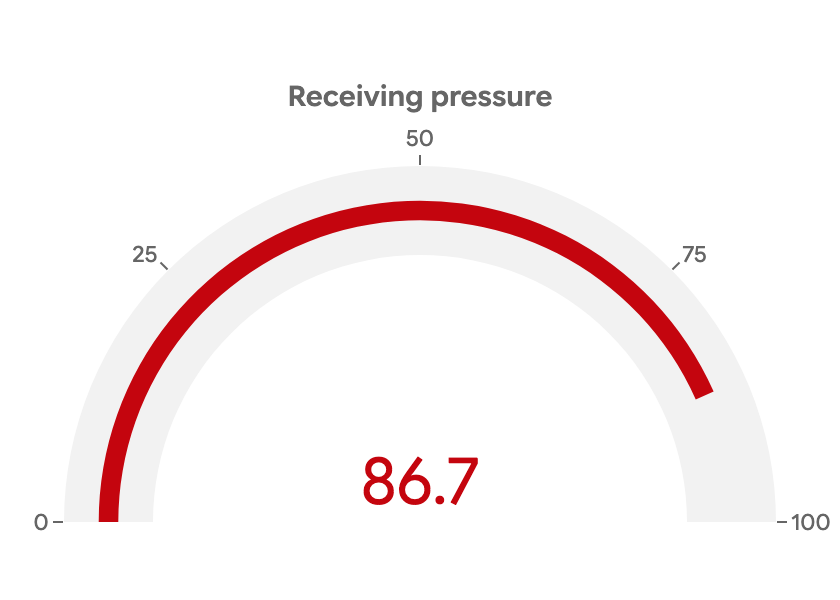

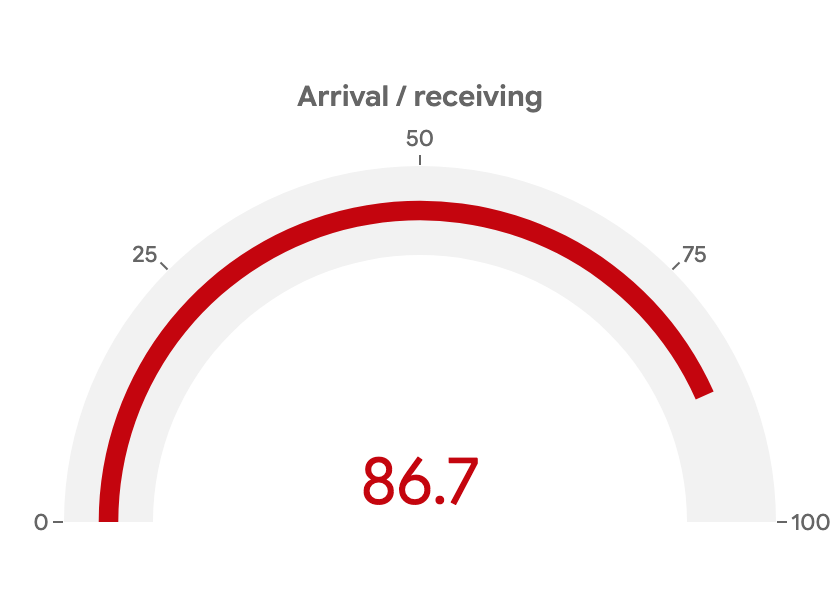

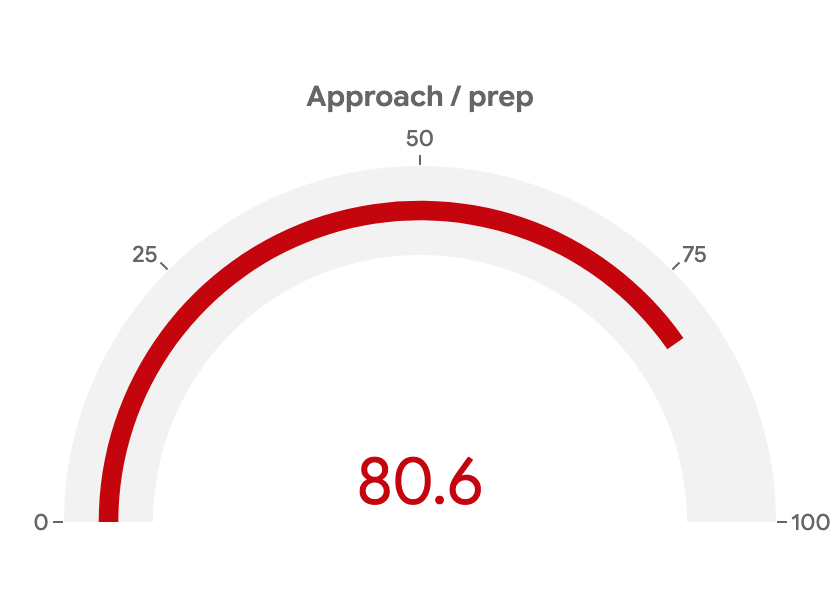

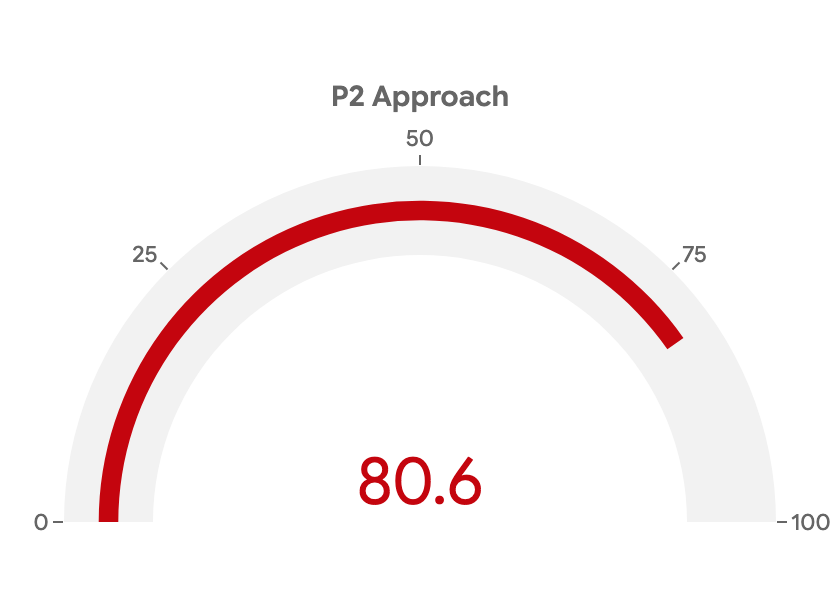

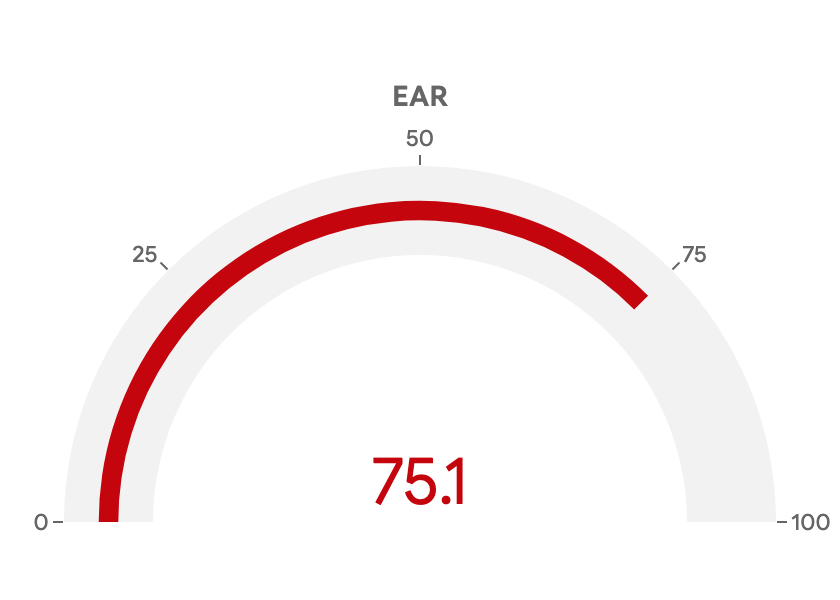

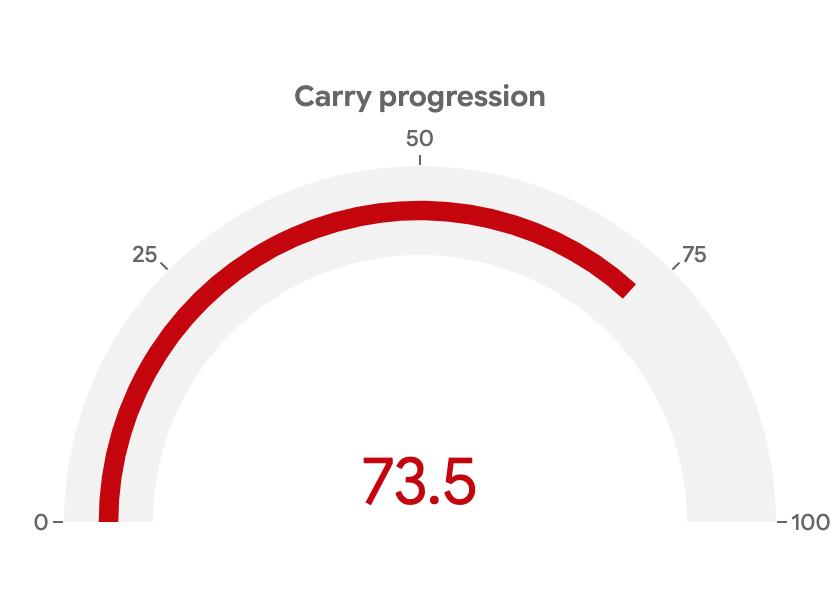

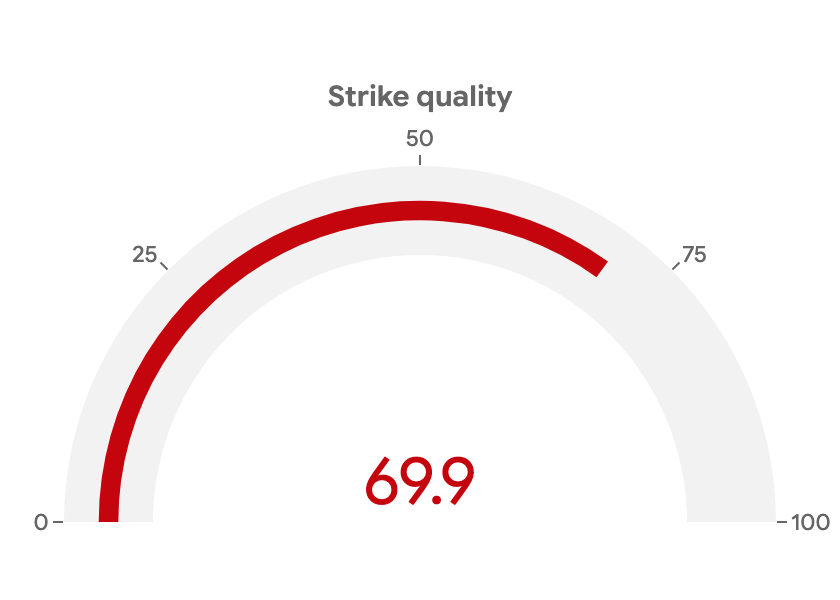

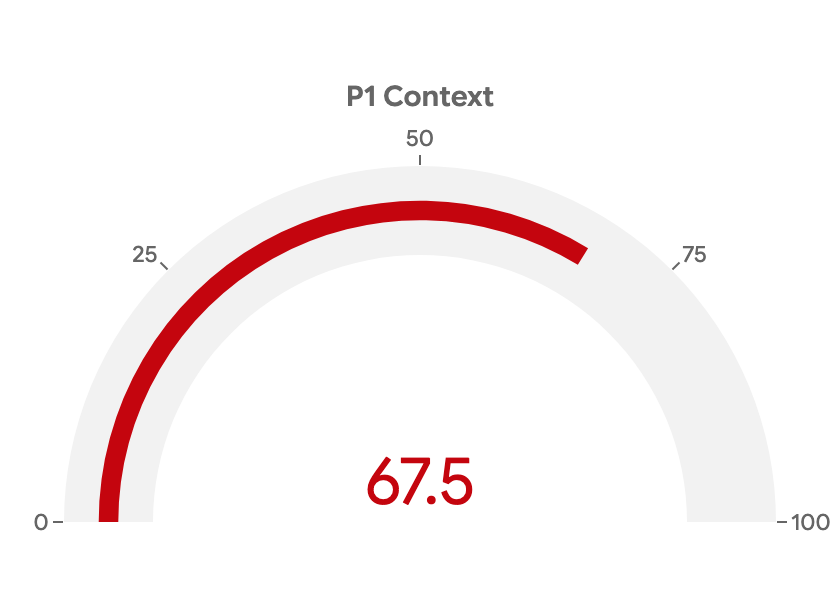

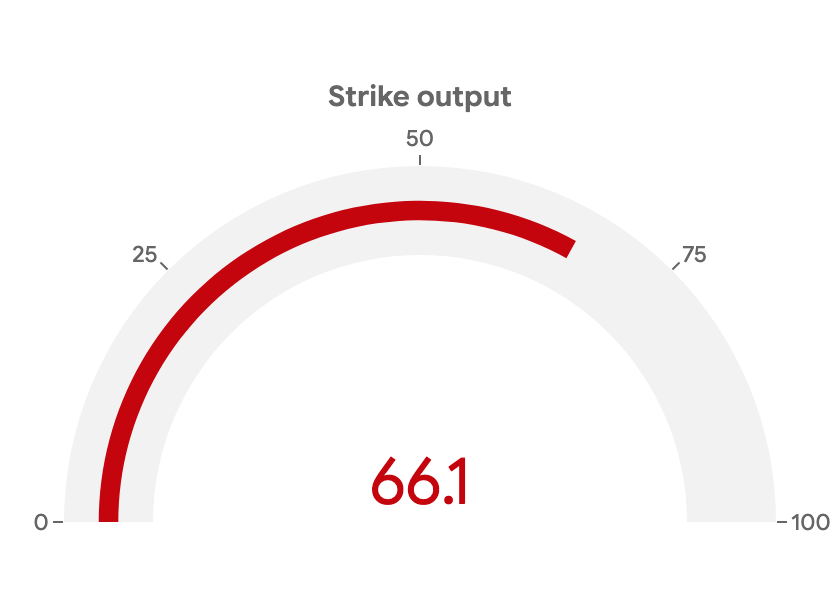

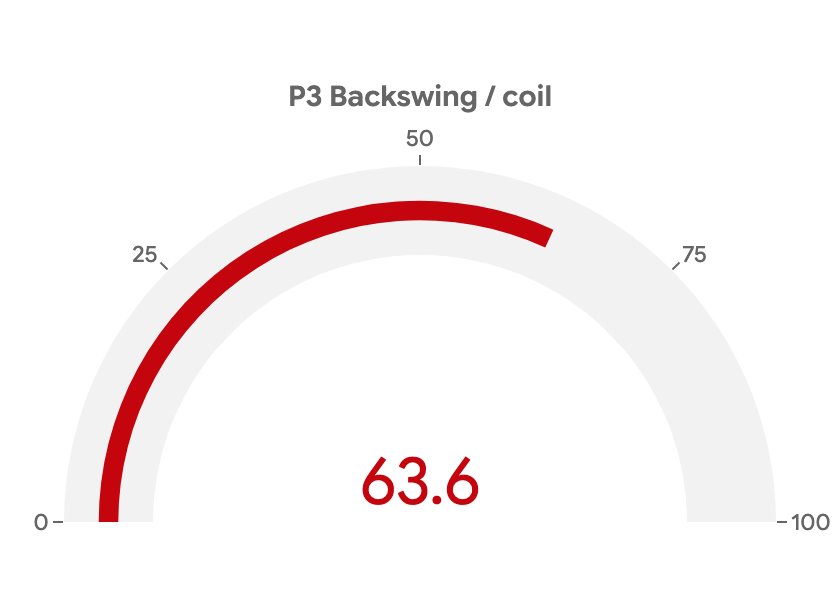

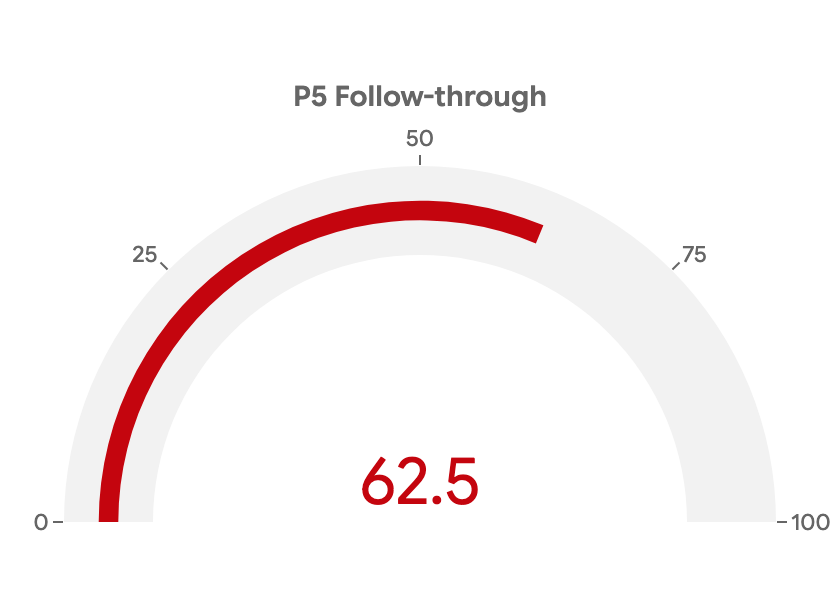

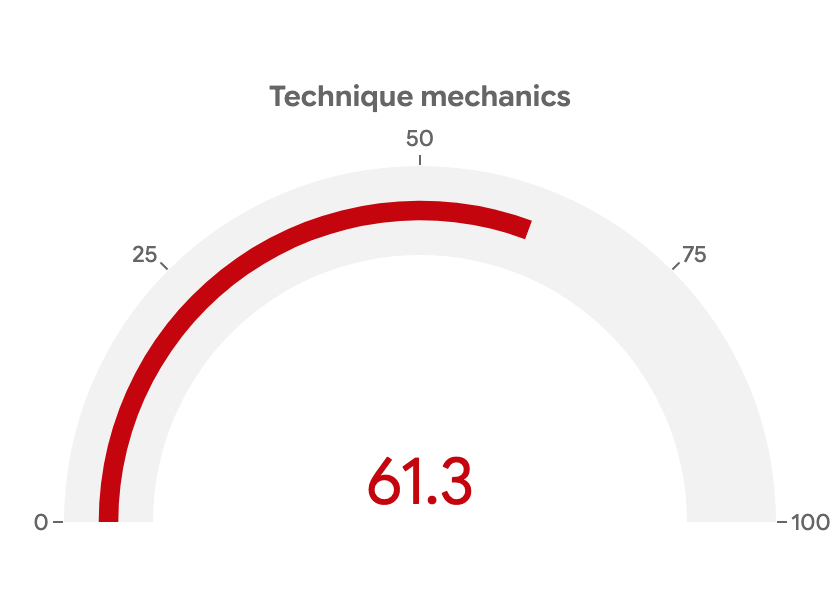

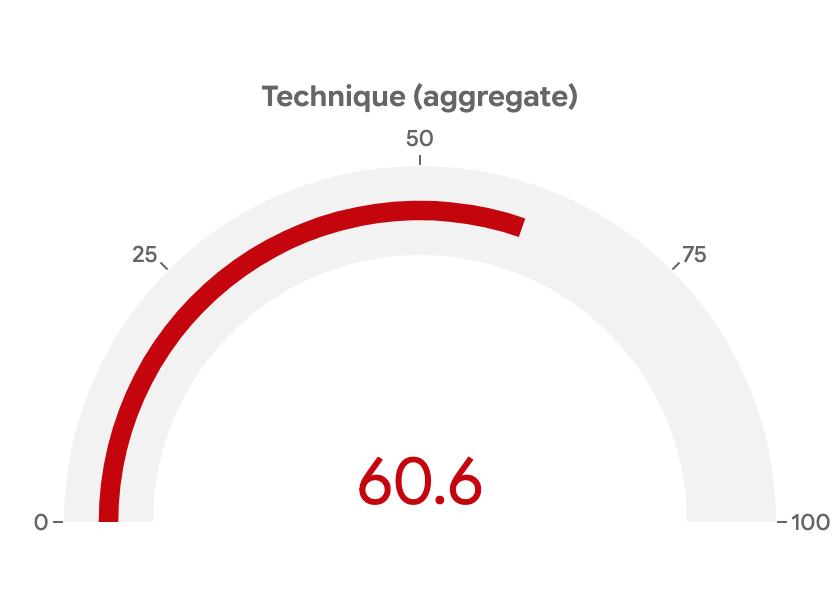

[('Receiving pressure', 86.69722222222221),
 ('Arrival / receiving', 86.69722222222221),
 ('Approach / prep', 80.59690719754613),
 ('P2 Approach', 80.59690719754613),
 ('EAR', 75.12667549475152),
 ('Carry progression', 73.47142857142858),
 ('Strike quality', 69.88885732673953),
 ('P1 Context', 67.52380505726028),
 ('Strike output', 66.12729977699763),
 ('P3 Backswing / coil', 63.628584226822234),
 ('P5 Follow-through', 62.54692973955908),
 ('Technique mechanics', 61.32409643728667),
 ('Technique (aggregate)', 60.624558472867534)]

In [9]:
highlights = display_player_speedometers(means, min_score=60)
highlights


### Interpretation (sample)

Across **6 shots** in this dataset, Kane averages ~**61** technique mechanics, ~**49** placement, ~**70** strike quality (see executed table above). **Finishing execution index** averages post-strike execution percentiles (strike quality, goal-plane lateral, exit speed, ball-to-foot ratio) — use it to explain xG overperformance, not decision or chance quality.